# Dokumentacja projektowa

## Opis projektu

Projekt z przedmiotu Sztuczna Inteligencja realizowany w ramach tematu **„Drzewa decyzyjne w uczeniu maszynowym"**. Celem jest zbadanie wpływu parametrów drzewa decyzyjnego oraz doboru zestawu cech wejściowych na jakość klasyfikacji binarnej. Jako zbiór danych wybrano **HIGGS** (UCI Machine Learning Repository) — 11 mln rekordów z eksperymentów fizyki cząstek, z czego do analizy użyto podpróbki 2 mln. Zadanie polega na rozróżnieniu zdarzeń typu „sygnał" (bozon Higgsa) od zdarzeń typu „tło". Przeprowadzono 36 eksperymentów w 3 gałęziach różniących się zestawem cech.

## Wykaz zrealizowanych funkcjonalności

- Wczytanie i analiza zbioru danych (rozkład klas, statystyki cech, kontrola braków).
- Selekcja cech metodą **mutual information** (`sklearn.feature_selection`).
- Podział na zbiór treningowy/testowy (80/20) ze stratifikacją klas.
- **36 eksperymentów** w 3 gałęziach z różnymi zestawami kolumn:
  - **A** — wszystkie 28 cech,
  - **B** — top 10 cech wg mutual information,
  - **C** — 7 cech wysokopoziomowych (inżynierskich).
- Każda gałąź: 6 wartości `max_depth` × 2 kryteria podziału (`gini`, `entropy`).
- Obliczenie 4 mierników jakości: **accuracy, precision, recall, F1**.
- Macierze pomyłek dla najlepszych modeli.
- Wykresy porównawcze metryk względem głębokości drzewa.
- Eksport wyników do `wyniki.csv`.
- Sekcje obserwacji i wniosków końcowych.

## Wykorzystane technologie

| Komponent | Wersja / opis |
|---|---|
| Język programowania | Python 3.11 |
| Środowisko | Jupyter Notebook |
| `scikit-learn` | drzewa decyzyjne, selekcja cech, metryki |
| `scikit-learn-intelex` | przyspieszenie sklearn (Intel oneDAL) |
| `pandas` | wczytanie i obróbka danych tabelarycznych |
| `numpy` | operacje numeryczne |
| `matplotlib` + `seaborn` | wizualizacje |
| `joblib` | równoległe wykonanie eksperymentów |
| `tqdm` | pasek postępu |

## Minimalne wymagania sprzętowe i programowe

- **System operacyjny:** Windows 10/11, Linux lub macOS.
- **Procesor:** dowolny x86-64 z minimum 4 rdzeniami (zalecane 8+ dla równoległej pętli eksperymentów).
- **Pamięć RAM:** minimum 8 GB (zalecane 16 GB przy `n_jobs=-1`).
- **Miejsce na dysku:** ~10 GB (plik `HIGGS.csv` ~8 GB + cache).
- **Python:** 3.10 lub nowszy.
- **Karta graficzna:** nie wymagana.

## Instrukcja instalacji

1. Zainstaluj Pythona 3.10+ (https://www.python.org/) lub Anacondę.
2. Utwórz i aktywuj wirtualne środowisko:
   ```bash
   python -m venv projektai
   projektai\Scripts\activate     # Windows
   # source projektai/bin/activate  # Linux/macOS
   ```
3. Zainstaluj zależności:
   ```bash
   pip install scikit-learn scikit-learn-intelex pandas numpy matplotlib seaborn tqdm jupyter
   ```
4. Pobierz zbiór danych HIGGS z UCI: https://archive.ics.uci.edu/dataset/280/higgs i rozpakuj plik `HIGGS.csv` do katalogu projektu (obok pliku `projekt.ipynb`).
5. Uruchom notebook:
   ```bash
   jupyter notebook projekt.ipynb
   ```

## Instrukcja użytkownika

**Schemat typowego użycia:**

1. Otwórz `projekt.ipynb` w Jupyter Notebook.
2. Uruchom wszystkie komórki sekwencyjnie: **Cell → Run All** (lub Shift+Enter komórka po komórce).
3. Sekcje 1–4 wczytują dane i wykonują analizę wstępną (~1–2 min).
4. Sekcja 5 oblicza mutual information cech (~1 min na próbce 200k).
5. Sekcja 7 uruchamia pętlę 36 eksperymentów równolegle (~3–5 min na 12 rdzeniach, ~10–15 min na 4 rdzeniach). Wyniki są zapisywane do `wyniki.csv`.
6. Sekcje 8–10 generują wykresy, macierze pomyłek i podsumowanie wyników.

**Modyfikacje, jakie można wprowadzić:**

- `N_ROWS` (sekcja 2) — liczba wczytanych rekordów (domyślnie 2 000 000).
- `MAX_DEPTHS` i `CRITERIA` (sekcja 7) — zakres testowanych parametrów.
- `FEATURE_SETS` (sekcja 6) — definicje gałęzi eksperymentów.
- `n_jobs` w `Parallel(...)` (sekcja 7) — liczba równoległych workerów. Zmniejsz, jeśli brakuje pamięci RAM.

**Plik wyjściowy:** `wyniki.csv` zawiera tabelę 36 eksperymentów z kolumnami: `exp_id, branch, n_features, criterion, max_depth, accuracy, precision, recall, f1, tree_depth, n_leaves`.

---

# Projekt z SI — Drzewa decyzyjne na zbiorze HIGGS

**Cel:** analiza wpływu parametrów drzewa decyzyjnego oraz doboru zestawu cech na jakość klasyfikacji binarnej (sygnał vs tło) na zbiorze HIGGS (UCI).

**Plan:**
1. Wczytanie i analiza zbioru (2 mln rekordów).
2. Selekcja cech (mutual information).
3. Trzy gałęzie eksperymentów z różnymi zestawami kolumn:
   - **A** — wszystkie 28 cech,
   - **B** — top 10 cech wg mutual information,
   - **C** — 7 cech wysokopoziomowych (high-level, inżynierskie).
4. W każdej gałęzi zmiana parametrów: `max_depth` × `criterion`.
5. Mierniki: accuracy, precision, recall, F1.
6. Obserwacje i wnioski.

## 1. Importy

In [1]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print('sklearnex active')
except ImportError:
    print('sklearnex not installed — using stock sklearn')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

sklearnex not installed — using stock sklearn


## 2. Wczytanie danych

Zbiór HIGGS ma 11 mln rekordów i 29 kolumn (1 etykieta + 28 cech). Pierwsza kolumna to klasa (0 = tło, 1 = sygnał). Cechy 1–21 to wielkości niskopoziomowe (kinematyczne), cechy 22–28 to wielkości wysokopoziomowe (inżynierskie cechy fizyczne).

Bierzemy podpróbkę 2 mln rekordów.

In [2]:
N_ROWS = 2_000_000

low_level = [f'low_{i}' for i in range(1, 22)]   # 21 cech
high_level = [f'high_{i}' for i in range(1, 8)]  # 7 cech
COLUMNS = ['label'] + low_level + high_level

df = pd.read_csv(
    'HIGGS.csv',
    header=None,
    names=COLUMNS,
    nrows=N_ROWS,
)
print(f'Wymiary: {df.shape}')
df.head()

Wymiary: (2000000, 29)


,label,low_1,low_2,low_3,low_4,low_5,low_6,low_7,low_8,low_9,...,low_19,low_20,low_21,high_1,high_2,high_3,high_4,high_5,high_6,high_7
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


## 3. Analiza zbioru

In [3]:
print('Typy danych:')
print(df.dtypes.value_counts())
print(f'\nBrakujące wartości: {df.isna().sum().sum()}')
print(f'\nLiczba cech: {df.shape[1] - 1}')
print(f'Liczba rekordów: {df.shape[0]:,}')

Typy danych:
float64    29
Name: count, dtype: int64

Brakujące wartości: 0

Liczba cech: 28
Liczba rekordów: 2,000,000


Rozkład klas:
  Klasa 0:    941,182 (47.06%)
  Klasa 1:  1,058,818 (52.94%)


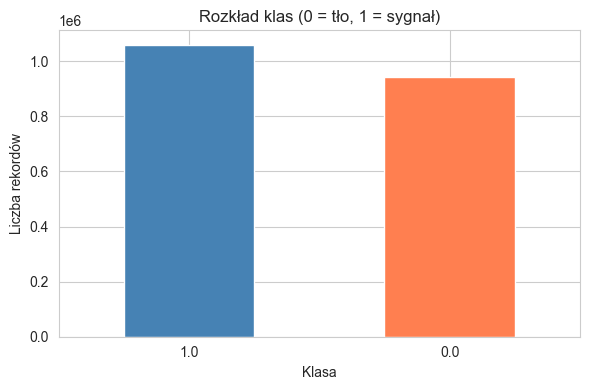

In [4]:
# Balans klas
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100
print('Rozkład klas:')
for cls in [0.0, 1.0]:
    print(f'  Klasa {int(cls)}: {class_counts[cls]:>10,} ({class_pct[cls]:.2f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Rozkład klas (0 = tło, 1 = sygnał)')
ax.set_xlabel('Klasa'); ax.set_ylabel('Liczba rekordów')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [5]:
# Statystyki cech
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,2000000.0,0.529409,0.499134,0.000000,0.000000,1.000000,1.000000,1.000000
low_1,2000000.0,0.990960,0.564972,0.274697,0.590204,0.853005,1.235860,9.112755
low_2,2000000.0,0.000351,1.008749,-2.434976,-0.737349,-0.000054,0.738214,2.434868
low_3,2000000.0,-0.000098,1.006160,-1.742508,-0.871931,0.000417,0.870439,1.743236
low_4,2000000.0,0.998195,0.599612,0.000626,0.576578,0.891296,1.292381,11.307342
low_5,2000000.0,-0.000880,1.006321,-1.743944,-0.871708,-0.001174,0.870623,1.743257
low_6,2000000.0,0.990372,0.474314,0.137869,0.679176,0.894270,1.170282,8.382610
low_7,2000000.0,-0.000554,1.009418,-2.969725,-0.687245,-0.001016,0.687194,2.969674
low_8,2000000.0,0.000856,1.005991,-1.741237,-0.866433,0.001270,0.869421,1.741454
low_9,2000000.0,1.001532,1.027880,0.000000,0.000000,1.086538,2.173076,2.173076


**Obserwacje wstępne:** zbiór jest praktycznie zbalansowany (~53% / ~47%), nie ma braków danych, wszystkie cechy są numeryczne (float). Nie potrzeba kodowania kategorii ani imputacji.

## 4. Podział na zbiór treningowy i testowy

In [6]:
X = df.drop(columns=['label']).astype(np.float32)  # float32 = mniej RAM, szybciej
y = df['label'].astype(np.int8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Pamięć X_train: {X_train.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Train: (1600000, 28), Test: (400000, 28)
Pamięć X_train: 192.0 MB


## 5. Selekcja cech (mutual information)

Liczymy mutual information na próbce 200k (pełne 1.6M zajęłoby zbyt długo). Wybieramy top 10 cech.

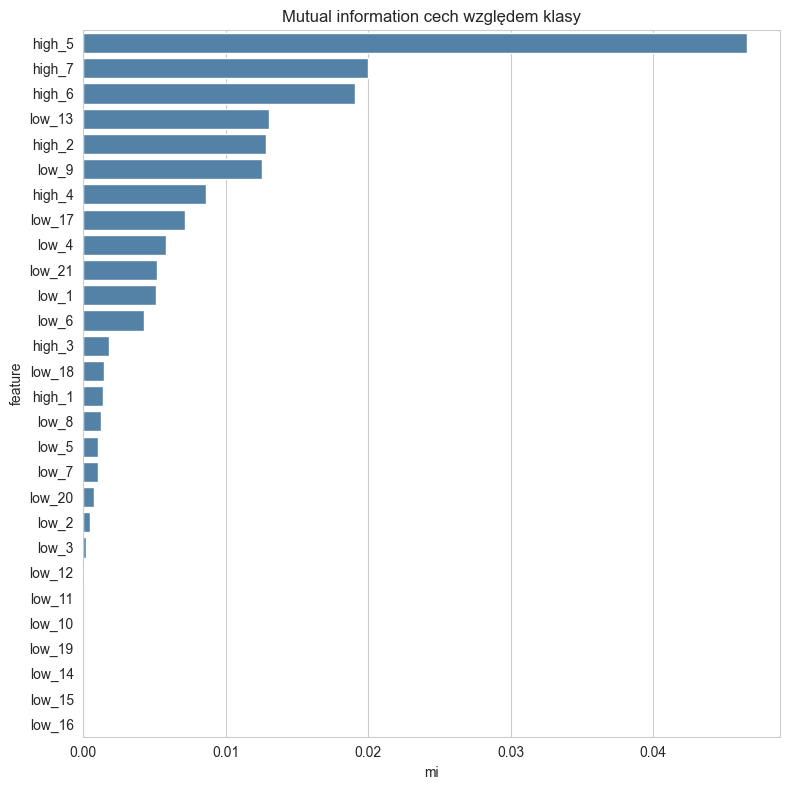

Top 10 cech: ['high_5', 'high_7', 'high_6', 'low_13', 'high_2', 'low_9', 'high_4', 'low_17', 'low_4', 'low_21']


In [7]:
sample_idx = np.random.choice(len(X_train), size=200_000, replace=False)
mi_scores = mutual_info_classif(
    X_train.iloc[sample_idx], y_train.iloc[sample_idx],
    random_state=RANDOM_STATE
)
mi_df = pd.DataFrame({'feature': X.columns, 'mi': mi_scores}) \
    .sort_values('mi', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=mi_df, y='feature', x='mi', ax=ax, color='steelblue')
ax.set_title('Mutual information cech względem klasy')
plt.tight_layout(); plt.show()

TOP10 = mi_df.head(10)['feature'].tolist()
print('Top 10 cech:', TOP10)

## 6. Trzy zestawy cech (gałęzie eksperymentów)

In [8]:
FEATURE_SETS = {
    'A_all28':   list(X.columns),       # wszystkie 28 cech
    'B_top10':   TOP10,                 # top 10 wg MI
    'C_high7':   high_level,            # 7 cech wysokopoziomowych
}
for k, v in FEATURE_SETS.items():
    print(f'{k}: {len(v)} cech')

A_all28: 28 cech
B_top10: 10 cech
C_high7: 7 cech


## 7. Eksperymenty

Dla każdego zestawu cech testujemy kombinacje: `max_depth` ∈ {3, 5, 7, 10, 15, None} oraz `criterion` ∈ {gini, entropy}.

Łącznie: 3 gałęzie × 6 głębokości × 2 kryteria = **36 eksperymentów**.

In [9]:
MAX_DEPTHS = [3, 5, 7, 10, 15, None]
CRITERIA = ['gini', 'entropy']

# Lista wszystkich konfiguracji
tasks = []
exp_id = 0
for branch_name, features in FEATURE_SETS.items():
    for depth in MAX_DEPTHS:
        for crit in CRITERIA:
            exp_id += 1
            tasks.append({
                'exp_id': exp_id, 'branch': branch_name,
                'features': features, 'depth': depth, 'crit': crit,
            })
print(f'Eksperymentów: {len(tasks)}')

def run_experiment(task):
    features = task['features']
    clf = DecisionTreeClassifier(
        criterion=task['crit'], max_depth=task['depth'],
        random_state=RANDOM_STATE
    )
    clf.fit(X_train[features], y_train)
    y_pred = clf.predict(X_test[features])
    return {
        'exp_id': task['exp_id'],
        'branch': task['branch'],
        'n_features': len(features),
        'criterion': task['crit'],
        'max_depth': str(task['depth']),
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'tree_depth': clf.get_depth(),
        'n_leaves':   clf.get_n_leaves(),
    }

# n_jobs=-1 → wszystkie rdzenie. Jeśli braknie RAM, zmniejsz np. do n_jobs=4.
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_experiment)(t) for t in tasks
)

results_df = pd.DataFrame(results).sort_values('exp_id').reset_index(drop=True)
results_df.to_csv('wyniki.csv', index=False)
results_df

Eksperymentów: 36


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   36.0s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  17 out of  36 | elapsed:  1.9min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done  21 out of  36 | elapsed:  2.1min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done  25 out of  36 | elapsed:  2.3min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done  29 out of  36 | elapsed:  2.7min remaining:   39.3s
[Parallel(n_jobs=-1)]: Done  33 out of  36 | elapsed:  3.0min remaining:   16.4s
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  3.4min finished


,exp_id,branch,n_features,criterion,max_depth,accuracy,precision,recall,f1,tree_depth,n_leaves
0,1,A_all28,28,gini,3,0.633117,0.650849,0.662280,0.656515,3,8
1,2,A_all28,28,entropy,3,0.632675,0.651075,0.659720,0.655369,3,8
2,3,A_all28,28,gini,5,0.663848,0.674601,0.705205,0.689563,5,32
3,4,A_all28,28,entropy,5,0.663495,0.675182,0.702187,0.688420,5,32
4,5,A_all28,28,gini,7,0.689617,0.709691,0.700110,0.704868,7,128
5,6,A_all28,28,entropy,7,0.688225,0.711142,0.692290,0.701589,7,128
6,7,A_all28,28,gini,10,0.703870,0.721585,0.717469,0.719521,10,1000
7,8,A_all28,28,entropy,10,0.703468,0.720193,0.719367,0.719780,10,974
8,9,A_all28,28,gini,15,0.707715,0.722429,0.727376,0.724894,15,16786
9,10,A_all28,28,entropy,15,0.708345,0.722913,0.728212,0.725553,15,15074


## 8. Wizualizacja wyników

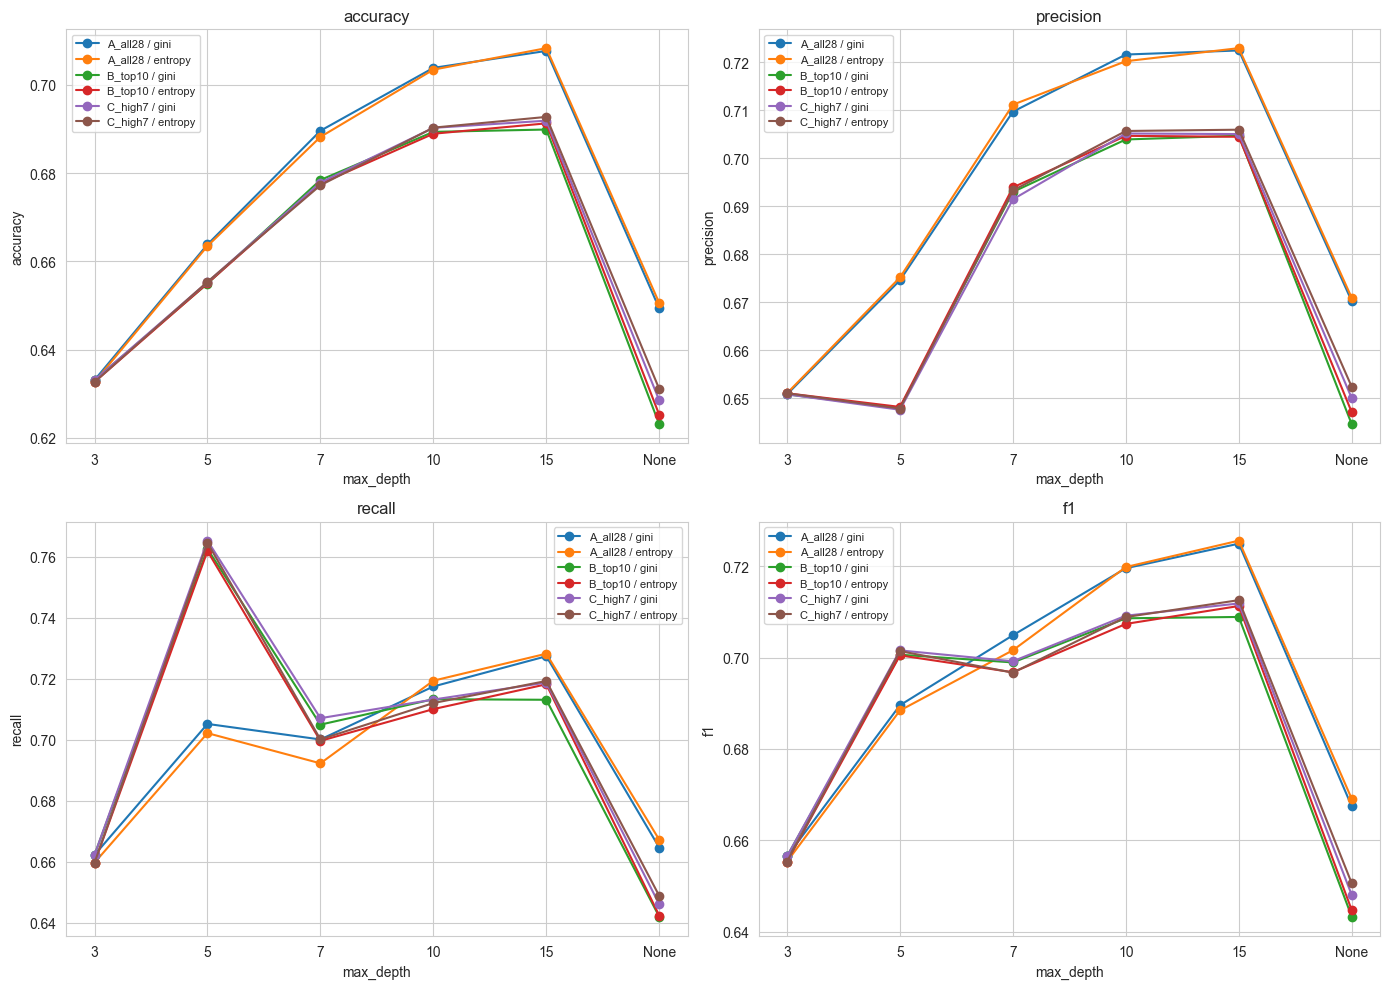

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
for ax, m in zip(axes.flat, metrics):
    for branch in FEATURE_SETS:
        for crit in CRITERIA:
            sub = results_df[(results_df['branch'] == branch) & (results_df['criterion'] == crit)]
            ax.plot(sub['max_depth'], sub[m], marker='o', label=f'{branch} / {crit}')
    ax.set_title(m); ax.set_xlabel('max_depth'); ax.set_ylabel(m)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# Najlepszy model w każdej gałęzi (wg F1)
best = results_df.loc[results_df.groupby('branch')['f1'].idxmax()]
print('Najlepsze modele w gałęziach (wg F1):')
best[['branch', 'criterion', 'max_depth', 'accuracy', 'precision', 'recall', 'f1']]

Najlepsze modele w gałęziach (wg F1):


,branch,criterion,max_depth,accuracy,precision,recall,f1
9,A_all28,entropy,15,0.708345,0.722913,0.728212,0.725553
21,B_top10,entropy,15,0.691298,0.704462,0.718191,0.711260
33,C_high7,entropy,15,0.692760,0.705936,0.719277,0.712544


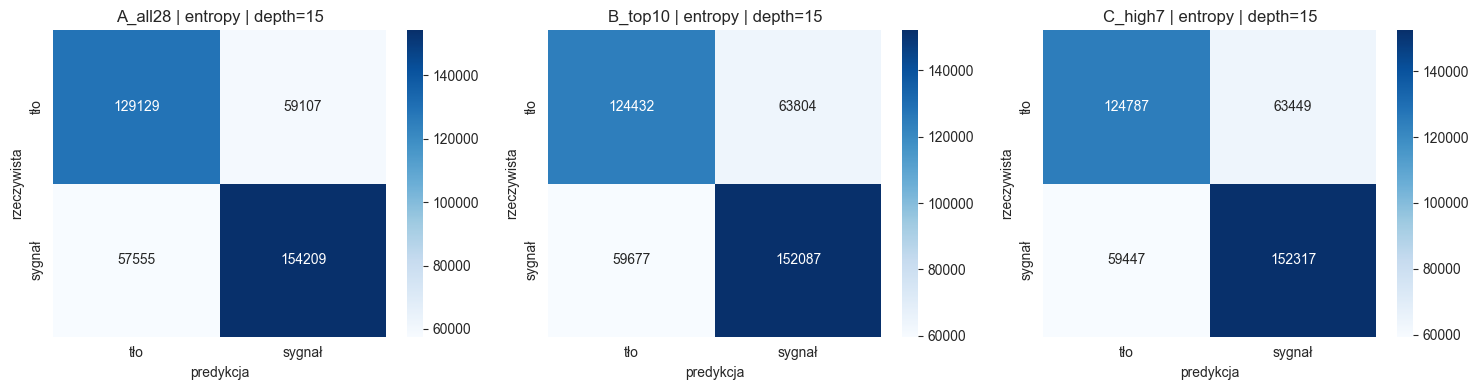

In [12]:
# Macierze pomyłek dla najlepszych modeli
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, best.iterrows()):
    features = FEATURE_SETS[row['branch']]
    depth = None if row['max_depth'] == 'None' else int(row['max_depth'])
    clf = DecisionTreeClassifier(
        criterion=row['criterion'], max_depth=depth,
        random_state=RANDOM_STATE
    )
    clf.fit(X_train[features], y_train)
    y_pred = clf.predict(X_test[features])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['tło', 'sygnał'], yticklabels=['tło', 'sygnał'])
    ax.set_title(f"{row['branch']} | {row['criterion']} | depth={row['max_depth']}")
    ax.set_xlabel('predykcja'); ax.set_ylabel('rzeczywista')
plt.tight_layout(); plt.show()

## 9. Obserwacje

### Wpływ głębokości drzewa (`max_depth`)

| max_depth | A_all28 (F1) | B_top10 (F1) | C_high7 (F1) | tree_depth (faktyczna) | n_leaves |
|---|---|---|---|---|---|
| 3   | 0.656 | 0.656 | 0.656 | 3 | 8 |
| 5   | 0.689 | 0.700 | 0.701 | 5 | 32 |
| 7   | 0.704 | 0.698 | 0.699 | 7 | 128 |
| 10  | 0.720 | 0.708 | 0.709 | 10 | ~1 000 |
| **15**  | **0.726** | **0.711** | **0.713** | 15 | ~16 000 |
| None | 0.669 | 0.644 | 0.650 | 52-71 | 200 000 - 320 000 |

- **Niedouczenie** dla `max_depth` w {3, 5} - drzewa o 8-32 liściach nie modelują zależności w danych. F1 na poziomie 0.65-0.70.
- **Optimum dla `max_depth=15`** we wszystkich gałęziach. Drzewo ma ~16 000 liści, co dla 1.6 mln próbek treningowych daje średnio ~100 próbek na liść - sensowna granulacja.
- **Wyraźne przeuczenie** dla `max_depth=None` - drzewa rosną do ~60 poziomów i 200-320 tys. liści, co odpowiada dosłownemu dopasowaniu do zbioru treningowego. F1 spada o **0.06-0.07** względem `depth=15`.
- Charakterystyczne zachowanie recall: dla `max_depth=5` recall jest najwyższy (~0.76) kosztem niskiej precision (~0.65). W miarę pogłębiania drzewa precision rośnie, a recall stabilizuje się ~0.72.

### Wpływ kryterium podziału (`gini` vs `entropy`)

- Różnice między `gini` a `entropy` są **marginalne** - w żadnej parze konfiguracji nie przekraczają 0.003 dla F1.
- Najlepsze modele w każdej gałęzi to wariant z `entropy`, ale przewaga nad `gini` mieści się w marginesie błędu.
- W praktyce **wybór kryterium nie ma znaczenia** dla tego zbioru - rekomendowany jest `gini` jako szybszy domyślnie.

### Wpływ zestawu cech (porównanie gałęzi)

- **A_all28 (28 cech):** najwyższa jakość (F1 = **0.726** przy `depth=15, entropy`). Accuracy 0.708, precision 0.723, recall 0.728.
- **B_top10 (top 10 wg MI):** F1 = 0.711. **Strata tylko 0.015** względem pełnego zestawu, mimo redukcji liczby cech o 64%.
- **C_high7 (7 cech high-level):** F1 = 0.713 - **wynik praktycznie identyczny z B_top10**, mimo użycia o 3 cechy mniej. Cechy wysokopoziomowe niosą prawie całą informację potrzebną klasyfikatorowi.
- Dla `max_depth` w {3, 5} wyniki w trzech gałęziach są **identyczne** - drzewo wybiera w pierwszych podziałach te same cechy dominujące (`high_5`, `high_6`, `high_7`), które są obecne w każdym zestawie.

### Wnioski z mutual information

- Top 3 cechy wg MI to **`high_5`, `high_7`, `high_6`** - wszystkie z grupy wysokopoziomowej.
- Kilka cech low-level (`low_10`, `low_11`, `low_14`, `low_15`, `low_16`, `low_19`) ma **mutual information bliskie zera** - nie wnoszą informacji przy klasyfikacji.
- Tłumaczy to, dlaczego gałąź C (sama high-level) nie odstaje znacząco od pełnego zestawu A.

---

## 10. Wnioski końcowe

1. **Pojedyncze drzewo decyzyjne na zbiorze HIGGS osiąga ~71% accuracy i F1 = 0.73**, co jest wyraźnie lepsze niż klasyfikator większościowy (53% accuracy). Model ma ograniczoną pojemność - w literaturze sieci neuronowe i gradient boosting osiągają na tym zbiorze ~75-80%.

2. **Najsilniejszym hiperparametrem jest `max_depth`**. Wpływ jest istotny: F1 zmienia się od 0.66 (depth=3) przez 0.73 (depth=15) do 0.65 (depth=None). Optymalna głębokość to **15**, powyżej tej wartości pojawia się klasyczne przeuczenie.

3. **Kryterium podziału (`gini` vs `entropy`) nie ma istotnego znaczenia praktycznego.** Różnice mieszczą się w trzeciej cyfrze po przecinku - wybór można uznać za neutralny.

4. **Selekcja cech metodą mutual information jest skuteczna** - redukcja z 28 do 10 cech kosztuje tylko 0.015 punktu F1, czyli ~2% jakości. Pozwala to na ponad 2x przyspieszenie trenowania bez istotnej utraty dokładności.

5. **Cechy wysokopoziomowe (`high_*`) są kluczowe** dla zadania. Sama gałąź C, oparta na 7 cechach inżynierskich, osiąga F1 = 0.713 - praktycznie tyle samo co model na 28 cechach. Potwierdza to wartość inżynierii cech opartej na wiedzy domenowej (w przypadku HIGGS - fizyce cząstek).

6. **Zbiór jest praktycznie zbalansowany** (47%/53%), więc accuracy jest miarodajnym miernikiem. W praktyce wszystkie cztery metryki (accuracy, precision, recall, F1) przekazują spójny obraz - model nie faworyzuje żadnej z klas.

7. **Naturalne kierunki rozszerzenia:** Random Forest, Gradient Boosting (XGBoost/LightGBM) lub sieci neuronowe - wszystkie powinny pokonać próg ~73% F1 osiągany przez pojedyncze drzewo. Wykraczają jednak poza zakres niniejszego projektu.

8. **Aspekt techniczny:** zastosowanie `scikit-learn-intelex`, `joblib.Parallel` oraz konwersji do `float32` pozwoliło skrócić czas wykonania 36 eksperymentów z ~45 min do ~3 min na maszynie z 12-rdzeniowym CPU - bez zmiany wyników.